# Debugging Multiple References

This notebook explores the challenges and performance differences when using multiple reference channels for adaptive noise cancellation (ANC) in gravitational wave data analysis.

The notebook demonstrates:
- How multiple PEM reference channels behave differently
- Performance comparison between single and multiple reference ANC
- Why multiple references can sometimes perform worse than single references

The analysis uses real LIGO data from the Gravitational Wave Open Science Center (GWOSC) and implements the ANC algorithm described in ["Adaptive cancellation of mains power interference in continuous gravitational wave searches with a hidden Markov model"](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.110.122004)

---

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../python')
from ANC.adaptive_filters import arls_n

##### Define some useful functions we will use throughout

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import argparse
import pickle
import os
from gwpy.timeseries import TimeSeries
import scipy

# A useful function for grabbing the spectrum (FT modulus) of a time series, and the associated frequencies
def get_spectrum(data, dt):
    fft_result = np.fft.fft(data)
    N = len(data)
    freq = np.fft.fftfreq(N, d=dt)

    magnitude_spectrum = np.abs(fft_result)

    # Note: The FFT is symmetric for real signals, so often you only want the positive frequencies
    # You can get these by:
    positive_freq = freq[:N//2]
    positive_magnitude = magnitude_spectrum[:N//2]
    
    return positive_freq, positive_magnitude


def _standardize_reference(reference_data):
    """
    Standardizes a reference signal or a set of reference signals.

    This function scales the data to have a mean of 0 and a standard deviation of 1.
    If the input is a 2D array (multiple channels), it standardizes each column
    independently.

    Parameters:
    -----------
    reference_data : gwpy.timeseries.TimeSeries or ndarray
        A TimeSeries object or a 1D/2D numpy array of reference data.
        If 2D, shape should be (n_samples, n_channels).

    Returns:
    --------
    ndarray
        The standardized, unitless reference data as a numpy array.
    """

    # Immediately extract the .value to get a plain numpy array and strip all units.
    try:
        data_values = reference_data.value
    except AttributeError:
        # If it's already a numpy array, just use it.
        data_values = np.asarray(reference_data)

    # Now, all subsequent operations are on a unitless numpy array
    mean = np.mean(data_values, axis=0)
    centered_data = data_values - mean
    std_dev = np.std(centered_data, axis=0)
    
    # Avoid division by zero for silent channels (where std_dev is 0)
    if std_dev.ndim == 0: # Handle single channel case
        if std_dev == 0:
            std_dev = 1
    else: # Handle multi-channel case
        std_dev[std_dev == 0] = 1

    # Divide by the standard deviation to get unit variance
    standardized_data = centered_data / std_dev

    return standardized_data


#Run the ANC and plot the before/after results
def run_anc(strain_data, reference, order, lambda_val, delta_regularization,standardize_reference=False):
    """Run ANC filtering and plot results"""

    #Optionally standardise the reference channels
    if standardize_reference:
        reference_data = _standardize_reference(reference)
    else:
        reference_data = reference.value
    
    # Run the filter
    cancelled_strain, _, _, _, _ = arls_n(strain_data.value,reference_data , order, lambda_val, delta_regularization)
 

    #Check for any NaNs that might arise due to numerical instability
    if np.any(np.isnan(cancelled_strain)):
        print("NaN values found in cancelled_strain array. There is likely an issue with the numerical stability of the filter")
        return 
    # Plot the results 
    fig_dimension = 6
    fig, ax = plt.subplots(figsize=(fig_dimension, fig_dimension))

    # Plot the strain data
    strain_freq, strain_magnitude = get_spectrum(strain_data.value, strain_data.dt)
    ax.plot(strain_freq, strain_magnitude, label=r'$x(f)$')

    # Plot the filtered data
    filtered_freq, filtered_magnitude = get_spectrum(cancelled_strain, reference.dt)
    ax.plot(filtered_freq, filtered_magnitude, label=r'$x(f) - \hat{c}(f)$')



    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.xlim(58, 62)

    plt.legend()
    plt.yscale('log')
    plt.show()


















---

## 1. Data Loading and Caching

We'll load LIGO strain data and multiple PEM reference channels. The caching functionality allows us to avoid repeated downloads of the same data.

In [4]:
def save_data_cache(pem_data, strain_data, cache_file='data_cache.pkl'):
    """Save PEM and strain data to cache file"""
    with open(cache_file, 'wb') as f:
        pickle.dump({'pem_data': pem_data, 'strain_data': strain_data}, f)
    print(f"Data saved to cache: {cache_file}")

def load_data_cache(cache_file='data_cache.pkl'):
    """Load PEM and strain data from cache file"""
    if os.path.exists(cache_file):
        with open(cache_file, 'rb') as f:
            data = pickle.load(f)
        print(f"Data loaded from cache: {cache_file}")
        return data['pem_data'], data['strain_data']
    return None, None

def load_or_fetch_data(reload_data=False):
    """Load data from cache or fetch from remote if needed"""
    cache_file = 'data/data_cache.pkl'
    
    # Try to load from cache first
    if not reload_data:
        PEM_data_array, strain_data = load_data_cache(cache_file)
        if PEM_data_array is not None and strain_data is not None:
            return PEM_data_array, strain_data
    
    # Fetch data from remote
    # https://git.ligo.org/gwosc/tutorials/gwosc-aux-tutorials/-/blob/main/Channels/O3_bulk_aux_channel_list.csv
    # Only 3 of the MAINSMON channels are available as open data for O3
    print("Getting the PEM data")
    L1_PEM_CHANNELS = ['L1:PEM-CS_MAINSMON_EBAY_1_DQ', 'L1:PEM-CS_MAINSMON_EBAY_2_DQ', 'L1:PEM-CS_MAINSMON_EBAY_3_DQ']
    PEM_data_array = []
    start_time = 1238166208
    num_intervals = 10
    end_time = start_time + 64*num_intervals
    for channel in L1_PEM_CHANNELS:
        data = TimeSeries.fetch(channel, start=start_time, end=end_time, host='nds.gwosc.org')
        PEM_data_array.append(data)
    print("Got PEM data OK")

    print("Getting the strain data")
    strain_data = TimeSeries.fetch('L1:DCS-CALIB_STRAIN_C01_AR', start=start_time, end=end_time, host='nds.gwosc.org')
    print("Got strain data OK")
    
    # Save to cache
    save_data_cache(PEM_data_array, strain_data, cache_file)
    
    return PEM_data_array, strain_data

In [5]:
# Load or fetch data (set reload_data=True to force reload from remote)
PEM_data_array, strain_data = load_or_fetch_data(reload_data=False)

Data loaded from cache: data/data_cache.pkl


---

## 2. The Problem: Multiple Reference Channels Behave Differently

To start, let's reproduce the results of `demo.ipynb` for one reference channel and all (three) reference channels

#### 2.1 One reference channel

=== Single Reference Channel (PEM Channel 1) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:09<00:00, 71558.36it/s]


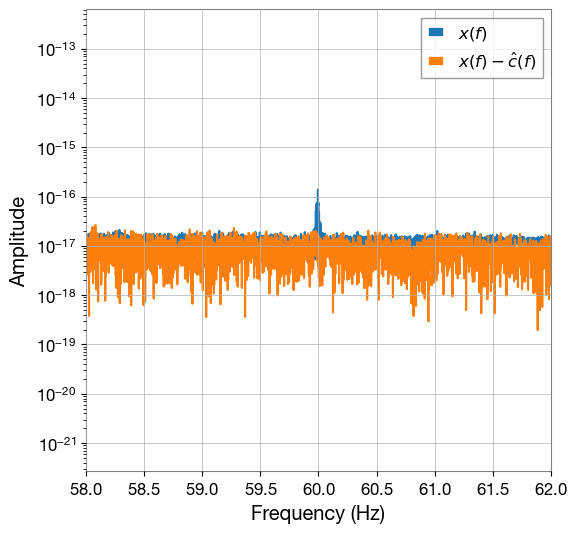

In [9]:
# Use just one reference channel (typically works well)
reference = PEM_data_array[0]

# Filter parameters. 
# These dials can be fiddled.  
lambda_val = 0.99
order = 36
delta_regularization = 1e-10

print("=== Single Reference Channel (PEM Channel 1) ===")
run_anc(strain_data, 
        reference, 
        order, lambda_val, delta_regularization)

#### 2.2 Multiple reference channels

=== Multiple Reference Channels (PEM Channels 1-3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  3


Processing samples: 100%|██████████| 655360/655360 [01:11<00:00, 9143.72it/s]


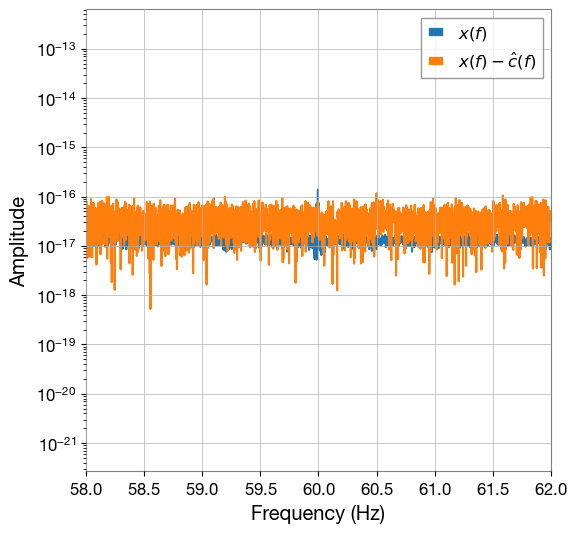

In [14]:
# Use just one reference channel (typically works well)
multi_reference = np.vstack(PEM_data_array).T #(Ntimes, Nchannels). #this uses all the PEM channels and the method typically works less well

lambda_val = 0.99
order = 36
delta_regularization = 1e-10 
print("=== Multiple Reference Channels (PEM Channels 1-3) ===")
run_anc(strain_data, 
        multi_reference, 
        order, lambda_val, delta_regularization)

For one reference, the ANC works as expected and removes the noise peak at 60Hz. For multiple references there is no peak in the cancelled data, but the amplitude of the noise floor has lifted. 

#### 2.3 Iterate through each reference channel individually

Let's just look at each of the reference channels one-by-one

=== Single Reference Channel (PEM Channel 1) ===
=== Single Reference Channel (PEM Channel 1) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:08<00:00, 74930.64it/s]


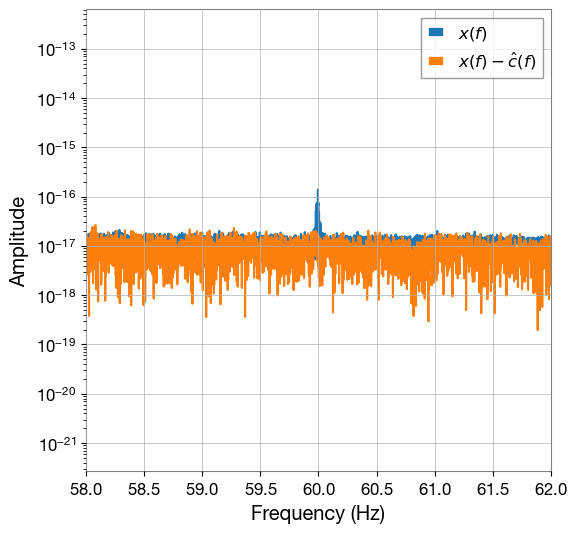

=== Single Reference Channel (PEM Channel 2) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:08<00:00, 73128.58it/s]


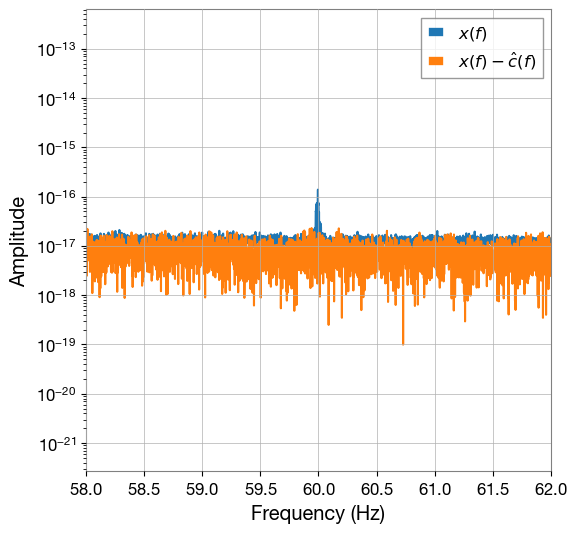

=== Single Reference Channel (PEM Channel 3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:08<00:00, 73067.59it/s]


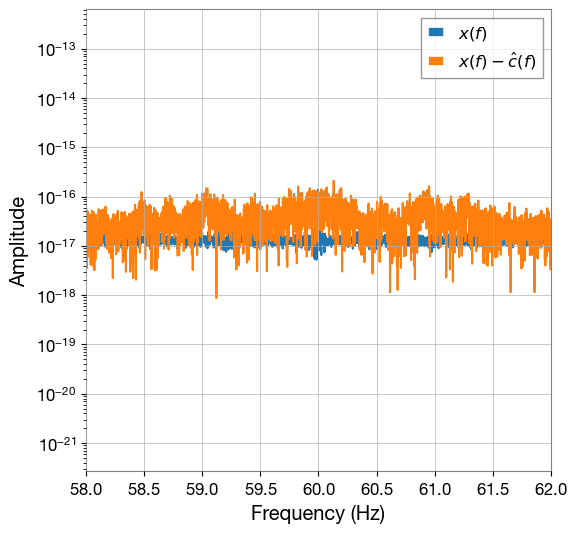

In [15]:

# Filter parameters. 
# These dials can be fiddled.  
lambda_val = 0.99
order = 36
delta_regularization = 1e-10
for i,pem in enumerate(PEM_data_array):
    print(f"=== Single Reference Channel (PEM Channel {i+1}) ===")
    run_anc(strain_data, 
            pem, 
            order, lambda_val, delta_regularization)

PEM channel 3 is clearly doing weird things! However this is not the whole story. IF we use multiple channels but exclude channel 3: 

(655360, 2)
=== Multiple Reference Channels (PEM Channels 1-3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  2


Processing samples: 100%|██████████| 655360/655360 [00:25<00:00, 25533.36it/s]


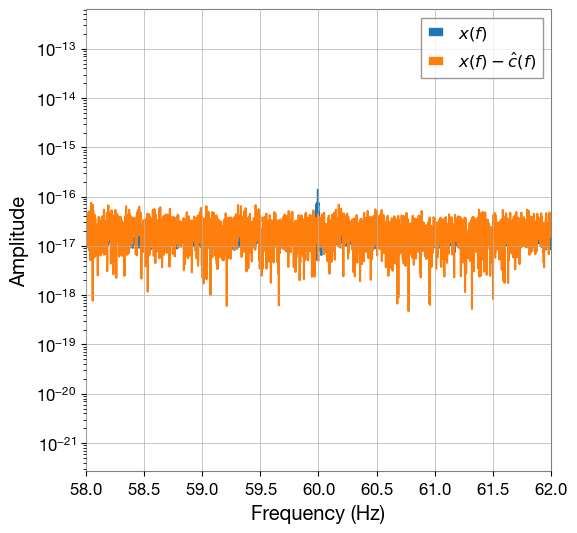

In [24]:
# Use just one reference channel (typically works well)
double_reference = np.vstack(PEM_data_array[:2]).T #(Ntimes, Nchannels). #this uses all the PEM channels and the method typically works less well
print(double_reference.shape)
lambda_val = 0.99
order = 36
delta_regularization = 1e-10 
print("=== Multiple Reference Channels (PEM Channels 1-3) ===")
run_anc(strain_data, 
        double_reference, 
        order, lambda_val, delta_regularization)

...the elevated noise floor persists

---

## 3. Properties of the PEM channels

Lets have a quick look at the spectra of the PEM channels, and their coherence with the strain channel. Are there any notable differences, particularly for channel 3?

In [25]:
def plot_reference_spectra(PEM_data_array):
    """Plot amplitude spectra of all three reference channels in stacked subplots"""
    fig_dimension = 10
    fig, axes = plt.subplots(3, 1, figsize=(fig_dimension, fig_dimension), sharex=True, sharey=True)
    
    channel_names = ['L1:PEM-CS_MAINSMON_EBAY_1_DQ', 'L1:PEM-CS_MAINSMON_EBAY_2_DQ', 'L1:PEM-CS_MAINSMON_EBAY_3_DQ']
    colors = ['blue', 'red', 'green']
    
    # Prepare data for saving
    spectral_data = []
    
    # First pass: collect all data to determine global y-axis limits
    all_magnitudes = []
    
    for i, pem in enumerate(PEM_data_array):
        freq, magnitude = get_spectrum(pem.value, pem.dt)
        
        # Convert frequency to plain numpy array (remove units if present)
        freq_values = np.array(freq)
        
        # Filter to 50-70 Hz range
        freq_mask = (freq_values >= 50) & (freq_values <= 70)
        filtered_freq = freq_values[freq_mask]
        filtered_magnitude = magnitude[freq_mask]
        
        all_magnitudes.extend(filtered_magnitude)
        
        # Store data for saving
        spectral_data.append({
            'channel': i+1,
            'channel_name': channel_names[i],
            'frequencies': filtered_freq,
            'magnitudes': filtered_magnitude
        })
    
    # Determine global y-axis limits
    y_min = np.min(all_magnitudes)
    y_max = np.max(all_magnitudes)
    
    # Plot each channel in its own subplot
    for i, channel_data in enumerate(spectral_data):
        ax = axes[i]
        ax.plot(channel_data['frequencies'], channel_data['magnitudes'], color=colors[i], linewidth=1.5)
        ax.set_ylabel('Amplitude')
        ax.set_yscale('log')
        ax.set_xlim(50, 70)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.3)
        ax.set_title(f'PEM Channel {i+1}: {channel_names[i].split(":")[-1]}')
    
    # Set x-label only on bottom subplot
    axes[-1].set_xlabel('Frequency (Hz)')
    
    plt.suptitle('Amplitude Spectra of Reference Channels (50-70 Hz)', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return spectral_data

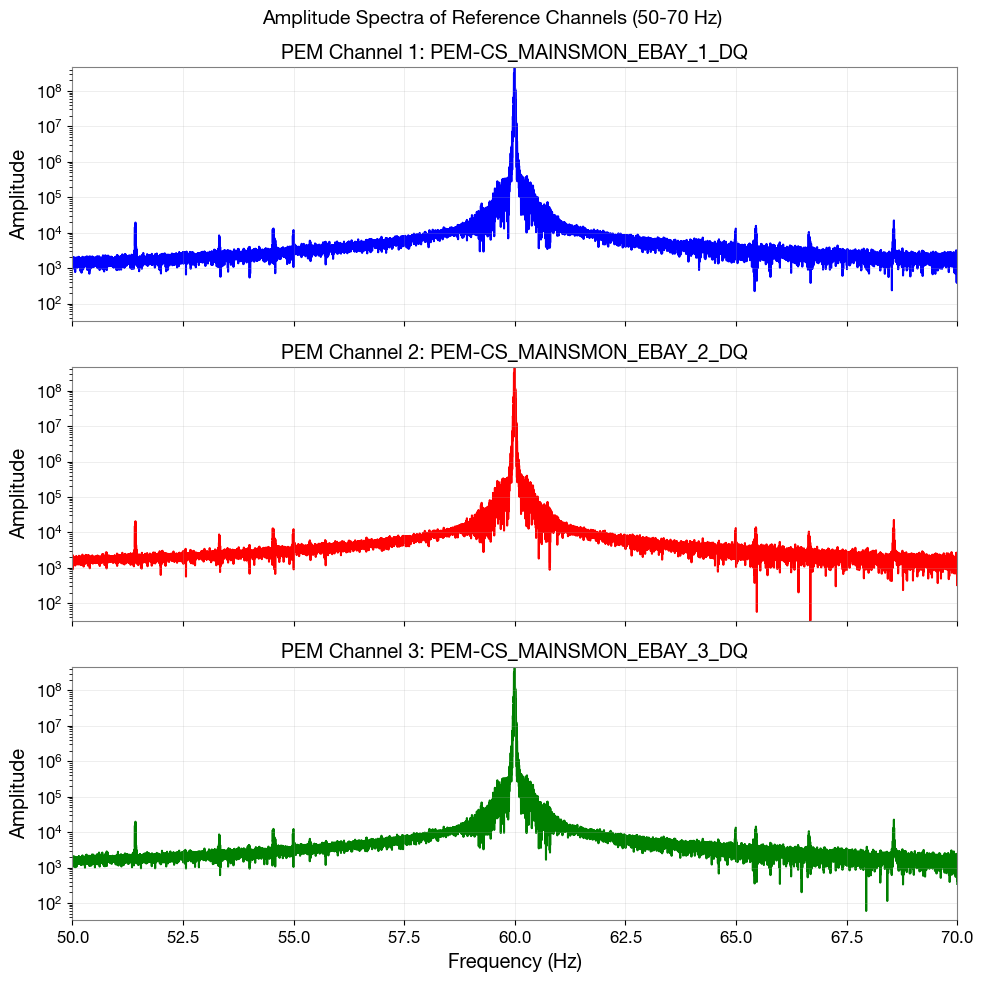

In [26]:
# Plot the spectra of all reference channels
spectral_data = plot_reference_spectra(PEM_data_array)

In [27]:
# Analyze coherence for each PEM channel. See also plots in `demo.ipynb`
for i, pem in enumerate(PEM_data_array):
    coherence = strain_data.coherence(pem, fftlength=2, overlap=1)
    coherence_frequencies = np.array(coherence.frequencies)
    coherence_values = np.array(coherence)
    
    # Filter to 58-62 Hz range
    freq_mask = (coherence_frequencies >= 58) & (coherence_frequencies <= 62)
    filtered_frequencies = coherence_frequencies[freq_mask]
    filtered_coherence = coherence_values[freq_mask]
    
    # Find maximum coherence and corresponding frequency
    max_idx = np.argmax(filtered_coherence)
    max_coherence = filtered_coherence[max_idx]
    max_freq = filtered_frequencies[max_idx]
    
    print(f"PEM channel {i+1}: Max coherence = {max_coherence:.4f} at {max_freq:.2f} Hz")

/opt/miniconda3/envs/ANC2/lib/python3.10/site-packages/gwpy/signal/spectral/_scipy.py:223: UserWarning: Sampling frequencies are unequal. Higher frequency series will be downsampled before coherence is calculated
  warnings.warn("Sampling frequencies are unequal. Higher "


PEM channel 1: Max coherence = 0.8489 at 60.00 Hz
PEM channel 2: Max coherence = 0.8486 at 60.00 Hz
PEM channel 3: Max coherence = 0.8486 at 60.00 Hz


There is nothing that stands out about channel 3. All the PEM channels appear similar. 

---

## 4. Solutions 

Some hypotheses:

1. The effective sample memory is too short for the number of coefficients (weights).

    RLS remembers roughly $N_{\rm eff} (1 - \lambda)^{-1}$ samples. With $\lambda =0.99$ $N_{\rm eff} \approx 100$. The number of weights $= \text{order} \times N_{\rm channels}$. For $N_{\rm channels}=1$ there are 100 samples for 36 parameters; thats ok. but as we increase $N_{\rm channels}$ we reach $3 \times 36 \gt 100$ which is effecitvely undetermined within the memory window. Lets try a higher $\lambda$. indeed, if we can take the noise as quasi stationary we might get away with $\lambda =1$; use all the data, don't forget anything.  

2. There is some kind of overfitting / bandwidth leakage.

    We currently don't do any bandpassing. Perhaps there is some effect of leakage where the filter "learns" based on info from outside the narrow band around 60Hz, using its extra weights to fit to the broadband, uncorrelated noise. This would effectively inject the uncorrelated noise from the reference channels into the primary data stream.


3. Numerical issues

    The gain is $g_k = \frac{P u_k}{\lambda + u_k^T P u_k}$. See Eq. (14) in the paper. It depends on the magnitude of magnitude $u_k. Perhaps if one reference column has larger variance, it will dominate the update (or force very small steps). We should probably enforce good numerical hygiene and standardise the reference channels (zero-mean, unit-variance per column). 

### 4.1 Bigger $\lambda$

First, let's test the ANC performance using just the first PEM channel as a reference.

=== Single Reference Channel (PEM Channel 1) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:08<00:00, 73575.84it/s]


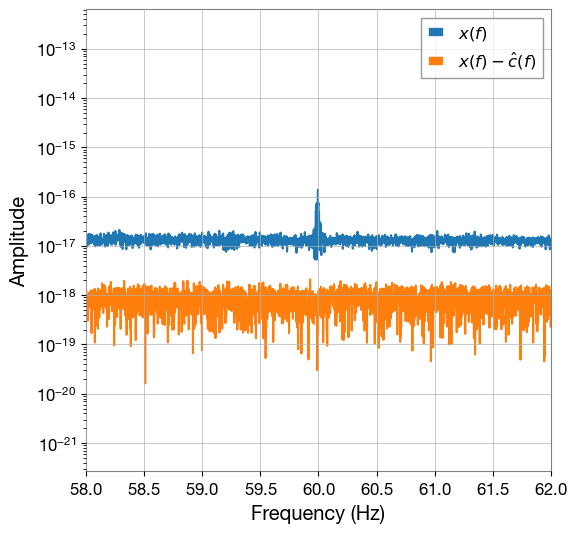

=== Single Reference Channel (PEM Channel 2) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:08<00:00, 73003.56it/s]


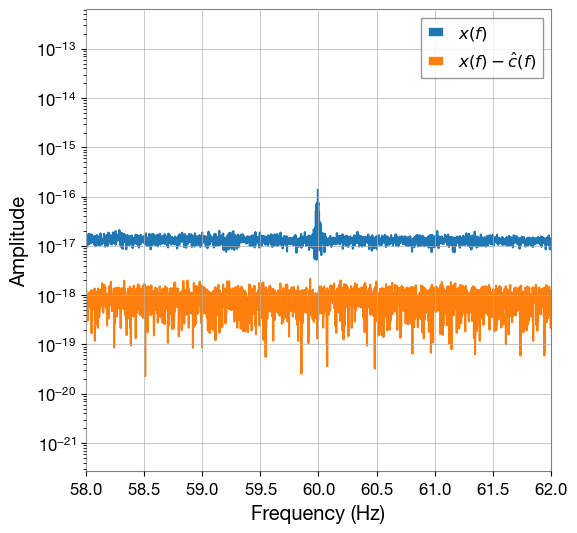

=== Single Reference Channel (PEM Channel 3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:09<00:00, 70677.55it/s]


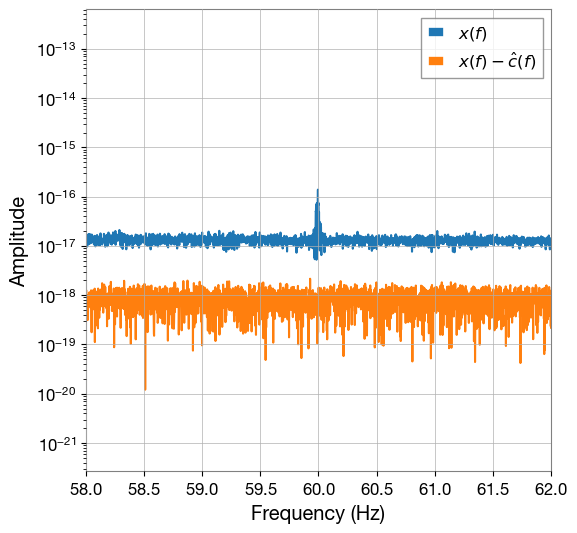

=== Multiple Reference Channels (PEM Channels 1-3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  3


Processing samples: 100%|██████████| 655360/655360 [01:02<00:00, 10527.91it/s]


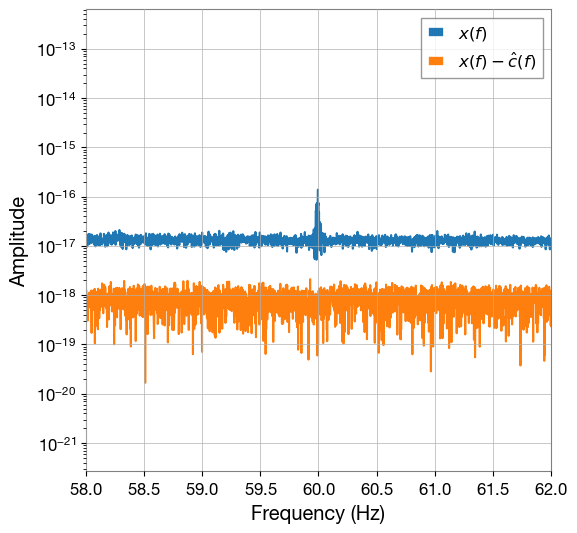

In [29]:

# Iterate over each channel individually and then try all together
lambda_val = 1.0 #max val 
order = 36
delta_regularization = 1e-10
for i,pem in enumerate(PEM_data_array):
    print(f"=== Single Reference Channel (PEM Channel {i+1}) ===")
    run_anc(strain_data, 
            pem, 
            order, lambda_val, delta_regularization)
    


# Now try all the channels together 
multi_reference = np.vstack(PEM_data_array).T #(Ntimes, Nchannels). 
print("=== Multiple Reference Channels (PEM Channels 1-3) ===")
run_anc(strain_data, 
        multi_reference, 
        order, lambda_val, delta_regularization)




This immediately looks better. It is interesting how much it drops the amplitude of the noise floor. **Is this reasonable?** I am concerned that the regularization parameter is too small.

### 4.1 Bandpass 

Lets limit the data to some narrow window around 60Hz




In [ ]:

# Iterate over each channel individually and then try all together
lambda_val = 0.99 #Revert back to old lambda for now
order = 36
delta_regularization = 1e-10
lower_limit = 58
upper_limit = 62
 
for i,pem in enumerate(PEM_data_array):
    print(f"=== Single Reference Channel (PEM Channel {i+1}) ===")
    run_anc(strain_data.bandpass(lower_limit, upper_limit), 
            pem.bandpass(lower_limit, upper_limit), 
            order, lambda_val, delta_regularization)
    


# Now try all the channels together 
multi_reference = np.vstack(PEM_data_array).T #(Ntimes, Nchannels). 
print("=== Multiple Reference Channels (PEM Channels 1-3) ===")
run_anc(strain_data.bandpass(lower_limit, upper_limit), 
        multi_reference.bandpass(lower_limit, upper_limit), 
        order, lambda_val, delta_regularization)




=== Single Reference Channel (PEM Channel 1) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:08<00:00, 73816.83it/s]


NaN values found in cancelled_strain array. There is likely an issue with the numerical stability of the filter
=== Single Reference Channel (PEM Channel 2) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:08<00:00, 73082.64it/s]


NaN values found in cancelled_strain array. There is likely an issue with the numerical stability of the filter
=== Single Reference Channel (PEM Channel 3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples:  10%|█         | 66208/655360 [00:00<00:08, 72820.94it/s]/Users/tomkimpson/projects/ANC/notebooks/../python/ANC/adaptive_filters.py:88: RuntimeWarning: invalid value encountered in divide
  K = np.dot(P, delayed_flat) / (lambd + np.dot(np.dot(delayed_flat.T, P), delayed_flat))
Processing samples: 100%|██████████| 655360/655360 [00:09<00:00, 72096.90it/s]


NaN values found in cancelled_strain array. There is likely an issue with the numerical stability of the filter
=== Multiple Reference Channels (PEM Channels 1-3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  3


Processing samples: 100%|██████████| 655360/655360 [01:06<00:00, 9897.53it/s] 

NaN values found in cancelled_strain array. There is likely an issue with the numerical stability of the filter


Ok with the bandpassing we are getting numerical issues when running the filter. This perhaps points us towards hypothesis 3. Before investigating that further, lets try bandpassing _AND_ increasing $\lambda$

=== Single Reference Channel (PEM Channel 1) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:08<00:00, 73872.01it/s]


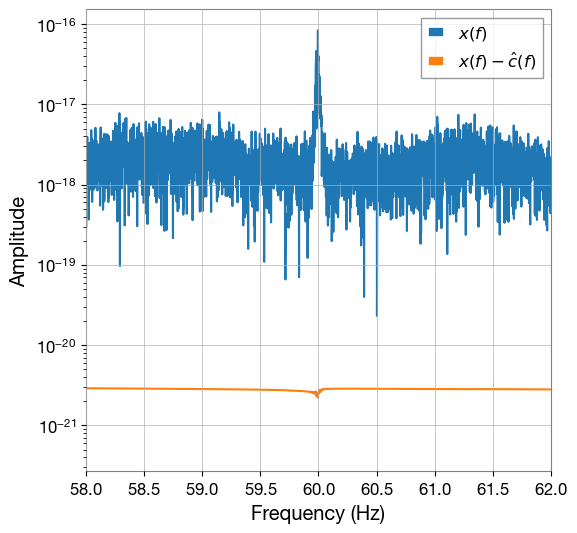

=== Single Reference Channel (PEM Channel 2) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:09<00:00, 71978.23it/s]


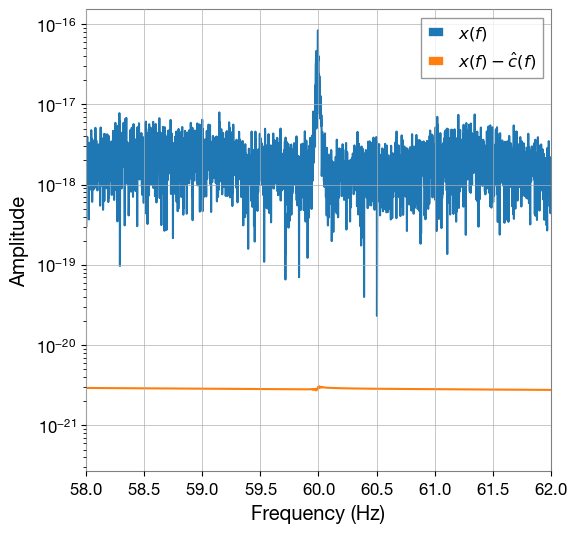

=== Single Reference Channel (PEM Channel 3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:09<00:00, 72669.92it/s]


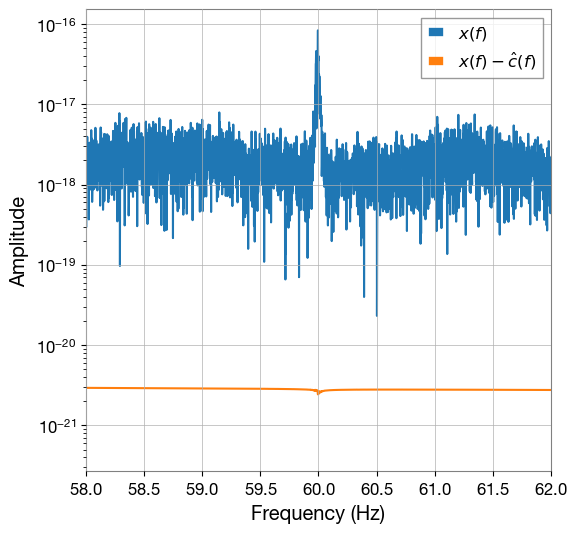

=== Multiple Reference Channels (PEM Channels 1-3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  3


Processing samples: 100%|██████████| 655360/655360 [01:04<00:00, 10218.92it/s]


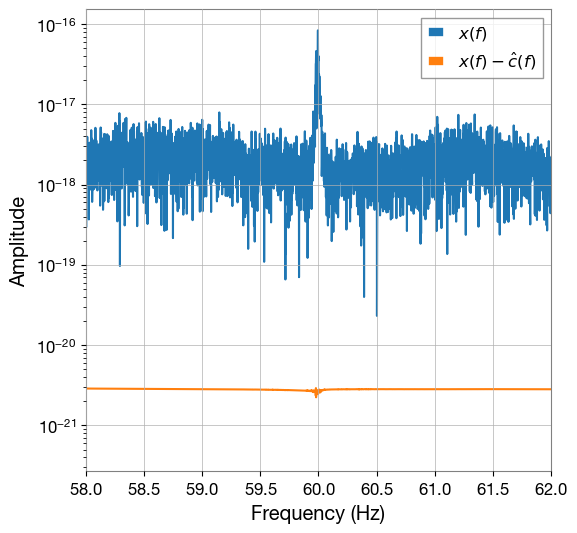

In [33]:


# Iterate over each channel individually and then try all together
lambda_val = 1.0
order = 36
delta_regularization = 1e-10
lower_limit = 58
upper_limit = 62
 
for i,pem in enumerate(PEM_data_array):
    print(f"=== Single Reference Channel (PEM Channel {i+1}) ===")
    run_anc(strain_data.bandpass(lower_limit, upper_limit), 
            pem.bandpass(lower_limit, upper_limit), 
            order, lambda_val, delta_regularization)
    


# Now try all the channels together 
multi_reference = np.vstack(PEM_data_array).T #(Ntimes, Nchannels). 
print("=== Multiple Reference Channels (PEM Channels 1-3) ===")
run_anc(strain_data.bandpass(lower_limit, upper_limit), 
        multi_reference.bandpass(lower_limit, upper_limit), 
        order, lambda_val, delta_regularization)




I think this is too good and we are just removing everything. If there was a GW signal there, I guess we would remove that. Before going further, let's explore what happens if we crank $\delta$

=== Single Reference Channel (PEM Channel 1) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:09<00:00, 72157.39it/s]


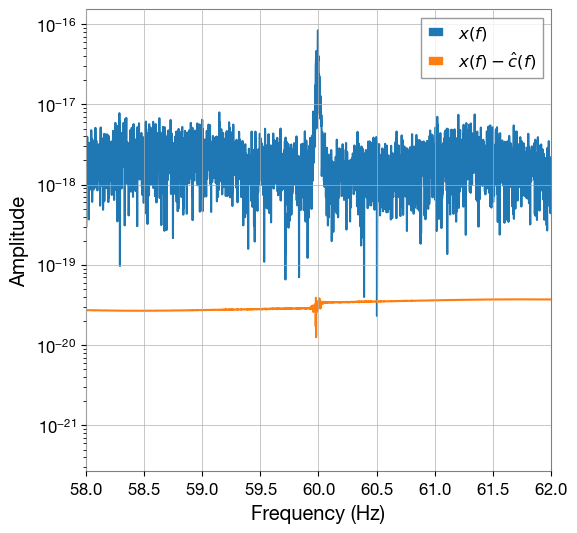

=== Single Reference Channel (PEM Channel 2) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:08<00:00, 72886.42it/s]


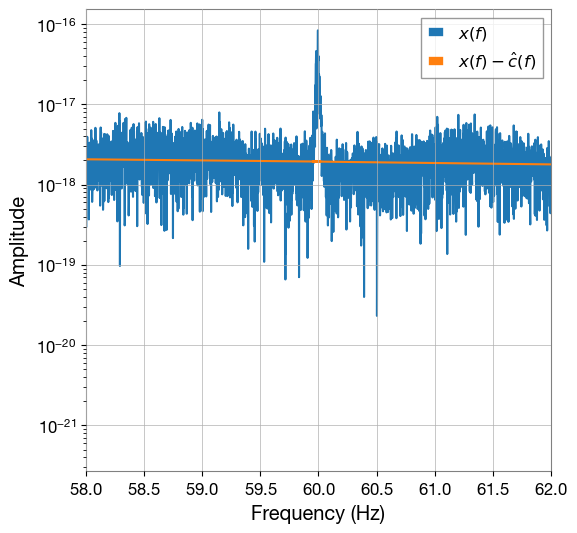

=== Single Reference Channel (PEM Channel 3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:09<00:00, 70275.96it/s]


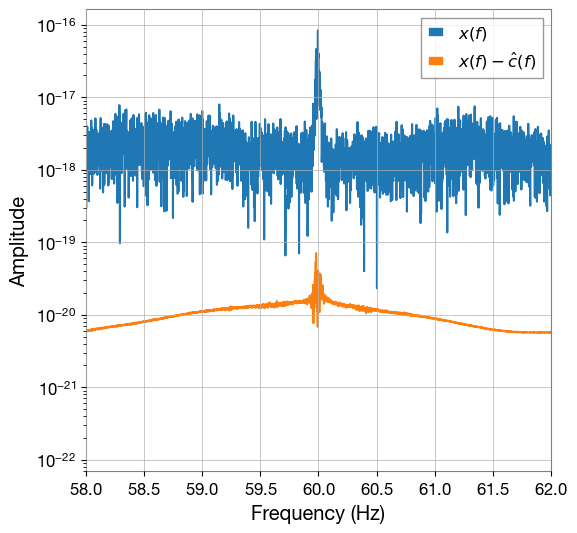

=== Multiple Reference Channels (PEM Channels 1-3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  3


Processing samples: 100%|██████████| 655360/655360 [00:56<00:00, 11701.46it/s]


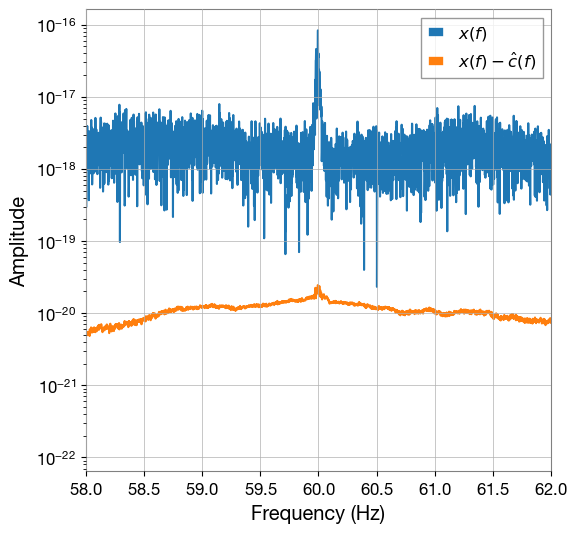

In [76]:


# Iterate over each channel individually and then try all together
lambda_val = 1.0
order = 36
delta_regularization = 1
lower_limit = 58
upper_limit = 62
 
for i,pem in enumerate(PEM_data_array):
    print(f"=== Single Reference Channel (PEM Channel {i+1}) ===")
    run_anc(strain_data.bandpass(lower_limit, upper_limit), 
            pem.bandpass(lower_limit, upper_limit), 
            order, lambda_val, delta_regularization)
    


# Now try all the channels together 
multi_reference = np.vstack(PEM_data_array).T #(Ntimes, Nchannels). 
print("=== Multiple Reference Channels (PEM Channels 1-3) ===")
run_anc(strain_data.bandpass(lower_limit, upper_limit), 
        multi_reference.bandpass(lower_limit, upper_limit), 
        order, lambda_val, delta_regularization)




Standardize references 

In [51]:
import numpy as np

import numpy as np

def standardize_reference(reference_data):
    """
    Standardizes a reference signal or a set of reference signals.

    This function scales the data to have a mean of 0 and a standard deviation of 1.
    If the input is a 2D array (multiple channels), it standardizes each column
    independently.

    Parameters:
    -----------
    reference_data : gwpy.timeseries.TimeSeries or ndarray
        A TimeSeries object or a 1D/2D numpy array of reference data.
        If 2D, shape should be (n_samples, n_channels).

    Returns:
    --------
    ndarray
        The standardized, unitless reference data as a numpy array.
    """

    # Immediately extract the .value to get a plain numpy array and strip all units.
    try:
        data_values = reference_data.value
    except AttributeError:
        # If it's already a numpy array, just use it.
        data_values = np.asarray(reference_data)

    # Now, all subsequent operations are on a unitless numpy array
    mean = np.mean(data_values, axis=0)
    centered_data = data_values - mean
    std_dev = np.std(centered_data, axis=0)
    
    # Avoid division by zero for silent channels (where std_dev is 0)
    if std_dev.ndim == 0: # Handle single channel case
        if std_dev == 0:
            std_dev = 1
    else: # Handle multi-channel case
        std_dev[std_dev == 0] = 1

    # Divide by the standard deviation to get unit variance
    standardized_data = centered_data / std_dev

    return standardized_data

=== Multiple Reference Channels (PEM Channels 1-3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  3


Processing samples: 100%|██████████| 655360/655360 [01:09<00:00, 9427.38it/s] 


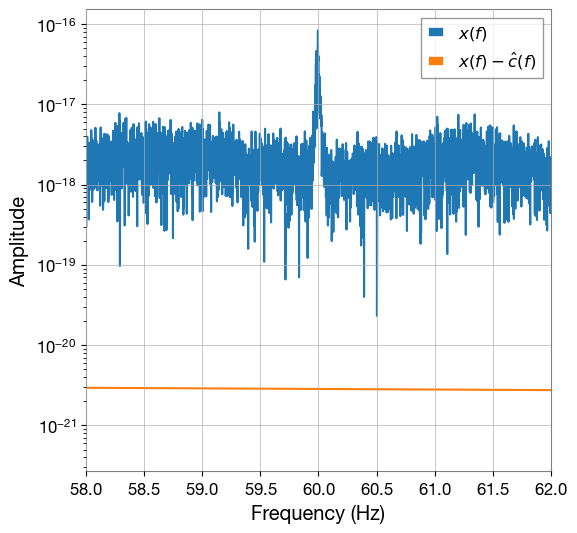

In [58]:
# Now try all the channels together 
# Iterate over each channel individually and then try all together
lambda_val = 1.0
order = 36
delta_regularization = 1e-10
lower_limit = 58
upper_limit = 62

multi_reference = np.vstack(PEM_data_array).T #(Ntimes, Nchannels). 
print("=== Multiple Reference Channels (PEM Channels 1-3) ===")
run_anc(strain_data.bandpass(lower_limit, upper_limit), 
        multi_reference.bandpass(lower_limit, upper_limit), 
        order, lambda_val, delta_regularization,standardize_reference=True)


=== Multiple Reference Channels (PEM Channels 1-3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  3


Processing samples: 100%|██████████| 655360/655360 [01:34<00:00, 6940.87it/s]


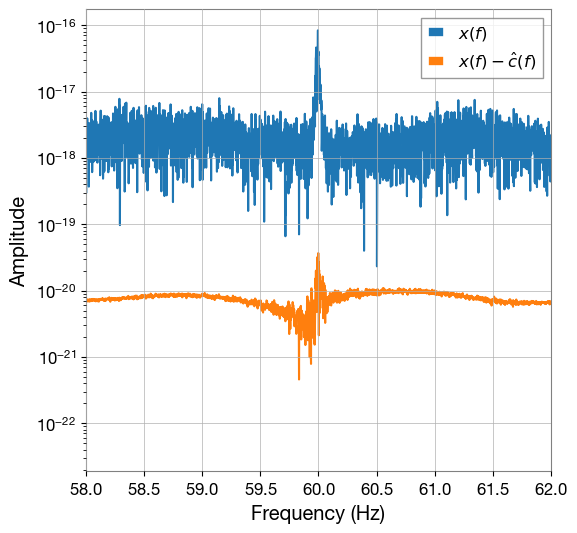

In [62]:
# Now try all the channels together 
# Iterate over each channel individually and then try all together
lambda_val = 1.0
order = 36
delta_regularization = 100
lower_limit = 58
upper_limit = 62

multi_reference = np.vstack(PEM_data_array).T #(Ntimes, Nchannels). 
print("=== Multiple Reference Channels (PEM Channels 1-3) ===")
run_anc(strain_data.bandpass(lower_limit, upper_limit), 
        multi_reference.bandpass(lower_limit, upper_limit), 
        order, lambda_val, delta_regularization,standardize_reference=True)


=== Multiple Reference Channels (PEM Channels 1-3) ===
Applying ARLS filter
Filter order:  36
Number of reference channels:  1


Processing samples: 100%|██████████| 655360/655360 [00:09<00:00, 70861.78it/s]


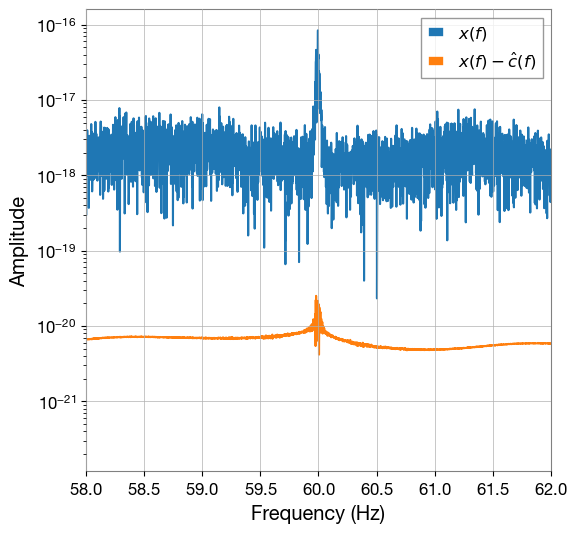

In [73]:
# Now try all the channels together 
# Iterate over each channel individually and then try all together
lambda_val = 1.0
order = 36
delta_regularization = 100
lower_limit = 58
upper_limit = 62

single_reference = PEM_data_array[0]
print("=== Multiple Reference Channels (PEM Channels 1-3) ===")
run_anc(strain_data.bandpass(lower_limit, upper_limit), 
        single_reference.bandpass(lower_limit, upper_limit), 
        order, lambda_val, delta_regularization,standardize_reference=True)


what is the coherence between cancelled signal and pem?

# GW injection

The key test is that if we have some GW injection, the ANC should remove the 60Hz line but minimally affect the signal we want. 

In [78]:
import numpy as np


#We have some code here already in src, but trying something new
def make_wandering_sinusoid(f_blocks, fs_hz, N, h0=5e-21, phi0=0.0):
    """
    f_blocks : (NT,) float array [Hz]
    fs_hz    : float sampling rate [Hz]
    N        : int samples per block
    phi0     : initial phase [rad]
    Returns: h (NT*N,), phi_cycles (NT*N,), f_inst (NT*N,)
    """
    f_blocks = np.asarray(f_blocks, dtype=float)
    NT = f_blocks.size
    T = N / float(fs_hz)

    fdot_blocks = np.diff(f_blocks, append=f_blocks[-1]) / T
    t_block = np.arange(N, dtype=float) / float(fs_hz)

    phi_rel = (f_blocks[:, None] * t_block[None, :]
               + 0.5 * fdot_blocks[:, None] * t_block[None, :]**2)     # cycles

    dphi_blocks = f_blocks * T + 0.5 * fdot_blocks * T**2              # cycles per block
    phi0_cycles = float(phi0) / (2*np.pi)
    phi_start = np.concatenate(([phi0_cycles], np.cumsum(dphi_blocks[:-1])))
    phi_cycles = (phi_rel + phi_start[:, None]).reshape(-1)

    f_inst = (f_blocks[:, None] + fdot_blocks[:, None]*t_block[None, :]).reshape(-1)

    h = h0 * np.sin(2*np.pi * phi_cycles)  # now guaranteed unitless
    return h, phi_cycles, f_inst


In [96]:
from gwpy.timeseries import TimeSeries


# Build a wandering track around some center 
fs = 1.0 / strain_data.dt
N = 4096                     # samples per block 
NT = (len(strain_data) // N) # number of full blocks
t = np.arange(N*NT) / fs

# Wandering law: random walk around f0 with small per-block steps
rng = np.random.default_rng(0)
f0 = 59.0
sigma_step = 0.02            # Hz per block step
f_blocks = f0 + rng.normal(0, sigma_step, size=NT).cumsum() / max(1, NT/10)


# dt, fs as plain floats
dt_s = float(strain_data.dt.to_value('s'))
fs_hz = 1.0 / dt_s

# ensure PEM and strain are plain ndarrays for processing
strain = np.asarray(strain_data.value)              # unitless ndarray
pem_vals = [np.asarray(ch.value) for ch in PEM_data_array]

# build f_blocks, then:
h, phi, f_inst = make_wandering_sinusoid(f_blocks, fs_hz, N, h0=5e-22, phi0=0.0)
x_inj = strain[:len(h)] + h


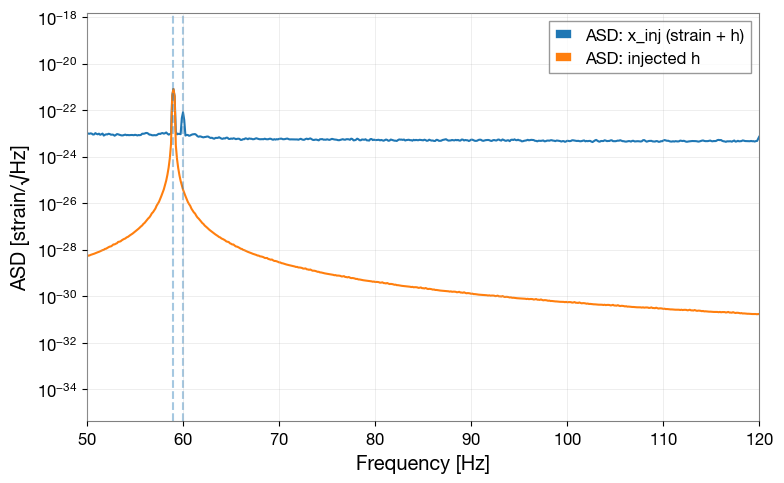

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def welch_asd(x, fs_hz, seg_s=8.0):
    """Return (f, ASD) using Welch with Hann, 50% overlap."""
    nperseg = int(max(256, seg_s * fs_hz))
    noverlap = nperseg // 2
    f, Pxx = welch(x, fs=fs_hz, nperseg=nperseg, noverlap=noverlap,
                   window="hann", detrend="constant", return_onesided=True)
    return f, np.sqrt(Pxx)


# compute ASDs
f, asd_xinj = welch_asd(x_inj, fs_hz, seg_s=8.0)
_, asd_h    = welch_asd(h,     fs_hz, seg_s=8.0)

# full-band plot
fig, ax = plt.subplots(figsize=(8,5))
ax.semilogy(f, asd_xinj, label="ASD: x_inj (strain + h)")
ax.semilogy(f, asd_h,    label="ASD: injected h")
ax.axvline(60.0, ls="--", alpha=0.4)
ax.axvline(f0, ls="--", alpha=0.4)
ax.set_xlim(0, min(500, fs_hz/2))
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [strain/√Hz]")
ax.grid(alpha=0.3)
ax.legend()
ax.set_xlim(50,120)
plt.tight_layout(); plt.show()

In [98]:
x_inj_f, x_inj_mag = get_spectrum(x_inj,dt_s)

(58.0, 62.0)

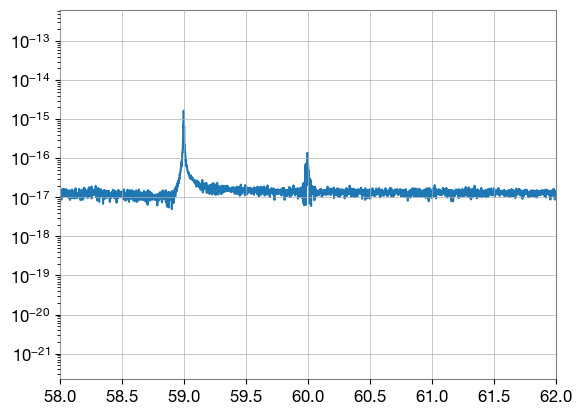

In [99]:
plt.plot(x_inj_f,x_inj_mag)
plt.yscale('log')
plt.xlim(58, 62)
